In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

X_train (xtrain) → Input features for the training set (e.g., age, height, weight).

y_train (ytrain) → Target labels for the training set (e.g., disease present or not).

X_test (xtest) → Input features for the test set (unseen data).

y_test (ytest) → Target labels for the test set (used to evaluate accuracy).

In [4]:
(X_train,y_train),(X_test,y_test)= datasets.cifar10.load_data()
# X_train.shape --> it tells you the dimensions of your training data.
X_train.shape

(50000, 32, 32, 3)

In [3]:
X_test.shape

(10000, 32, 32, 3)

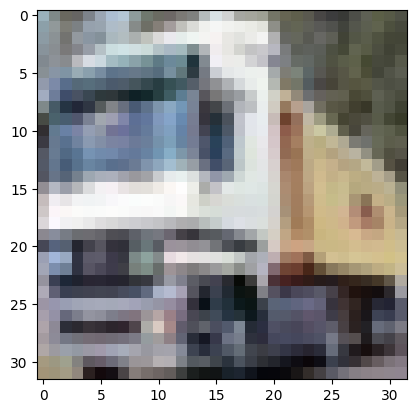

In [8]:
plt.imshow(X_train[1])

In [10]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [36]:
# y_train = y_train.reshape(-1,)
# y_train[:5]

In [5]:
classes = ["airplane","automobile","bird","cat","frog","horse","ship","truck"]

In [10]:
def plot_sample(X,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

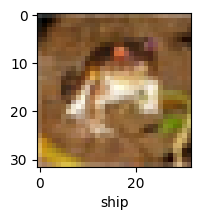

In [39]:
plot_sample(X_train,y_train,0)

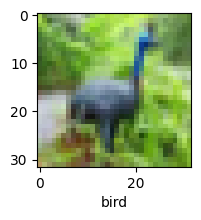

In [55]:
plot_sample(X_train,y_train,6)

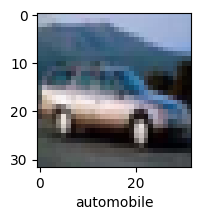

In [56]:
plot_sample(X_train,y_train,4)

In [6]:
X_train = X_train/255
X_test= X_test /255


In [45]:
ann = models.Sequential([
    layers.Flatten(input_shape =(32,32,3)),
    layers.Dense(3000,activation='relu'),
    layers.Dense(1000,activation='relu'),
    layers.Dense(10,activation='sigmoid')
])

ann.compile(optimizer ='SGD'
,loss ='sparse_categorical_crossentropy',
 metrics=['accuracy'])

ann.fit(X_train,y_train,epochs=5)

c:\MLProject\CNN\cnnvenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 83ms/step - accuracy: 0.3530 - loss: 1.8103
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 110s 70ms/step - accuracy: 0.4287 - loss: 1.6202
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 72ms/step - accuracy: 0.4581 - loss: 1.5396
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 65ms/step - accuracy: 0.4774 - loss: 1.4796
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 129s 56ms/step - accuracy: 0.4964 - loss: 1.4307


In [59]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]
print("Classification report :\n" ,classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
Classification report :
               precision    recall  f1-score   support

           0       0.71      0.27      0.40      1000
           1       0.74      0.42      0.54      1000
           2       0.29      0.54      0.38      1000
           3       0.40      0.23      0.29      1000
           4       0.38      0.46      0.41      1000
           5       0.39      0.42      0.40      1000
           6       0.50      0.54      0.52      1000
           7       0.55      0.50      0.52      1000
           8       0.46      0.77      0.57      1000
           9       0.64      0.44      0.52      1000

    accuracy                           0.46     10000
   macro avg       0.51      0.46      0.46     10000
weighted avg       0.51      0.46      0.46     10000



1. Activation Functions

Activation functions decide whether a neuron should fire or not.
Without them, a neural network would just be a linear function (like a straight line) and couldn’t learn complex patterns.

2. Optimizers

Optimizers are algorithms that update the weights of the network to reduce error (loss).

In [7]:
cnn = models.Sequential([
    #cnn 
    # input_shape -->Defines the shape of the input image for the first layer only.
    layers.Conv2D(filters=32, kernel_size=(3,3) ,activation='relu',input_shape=(32,32,3)),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3) ,activation='relu'),
    layers.MaxPool2D((2,2)),

    # dense
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

c:\MLProject\CNN\cnnvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
cnn.fit(X_train,y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.4849 - loss: 1.4358
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6141 - loss: 1.0984
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6658 - loss: 0.9641
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.6972 - loss: 0.8771
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7191 - loss: 0.8070
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7380 - loss: 0.7506
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.7568 - loss: 0.6951
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7729 - loss: 0.6526
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.7868 - loss: 0.6089
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8010 - loss: 0.5662


In [21]:
y_test = y_test.reshape(-1)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

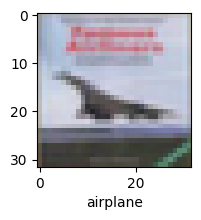

In [22]:
plot_sample(X_test,y_test,3)

In [23]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[1.57237679e-04, 1.87677448e-03, 1.22966887e-02, 9.04924631e-01,
        1.16128474e-04, 2.96671335e-02, 1.52927097e-02, 3.84999876e-05,
        3.53999957e-02, 2.30163641e-04],
       [6.08233502e-04, 3.20706852e-02, 3.16112687e-06, 4.90204783e-08,
        2.45832172e-08, 4.15567025e-10, 3.31875555e-10, 3.08842174e-09,
        9.66860890e-01, 4.57031856e-04],
       [5.00893593e-02, 1.08488068e-01, 1.39630414e-04, 4.29708464e-03,
        4.68259423e-05, 7.74088403e-05, 2.15611813e-04, 2.60126253e-05,
        8.14551890e-01, 2.20681988e-02],
       [9.89397764e-01, 6.79019024e-04, 8.66054732e-04, 3.73346003e-04,
        4.90203201e-05, 3.74917508e-05, 1.49516447e-04, 1.53858055e-05,
        8.29209294e-03, 1.40252101e-04],
       [2.04499747e-06, 2.03336349e-05, 1.42988563e-02, 2.80201882e-02,
        4.36240762e-01, 6.46467553e-04, 5.20732224e-01, 9.26636346e-07,
        1.75450768e-05, 2.06325021e-05]], dtype=float32)

In [24]:
y_classes  =[np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print("Classification report :\n" ,classification_report(y_test,y_classes))

Classification report :
               precision    recall  f1-score   support

           0       0.70      0.78      0.74      1000
           1       0.84      0.81      0.82      1000
           2       0.67      0.54      0.60      1000
           3       0.52      0.51      0.51      1000
           4       0.64      0.67      0.65      1000
           5       0.63      0.61      0.62      1000
           6       0.71      0.83      0.76      1000
           7       0.80      0.70      0.75      1000
           8       0.84      0.81      0.82      1000
           9       0.75      0.84      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000




Using Flatten layer so that we don't have to call .reshape on input dataset